### Phase vs. amplitude encoding in the Hopf (Stuart–Landau) model

This notebook reproduces **Figure 3** by simulating two Stuart–Landau (Hopf) oscillators coupled via a transient unidirectional link and quantifying how much stimulus-related information is carried by the joint amplitude A vs. the phase difference Δθ.

**Workflow:**
1. Configure environment and imports.
2. Define simulation parameters and the coupling profile.
3. Run the vectorised simulation across all trials.
4. Extract A and Δθ from the analytic signal; compute GC-MI.
5. Decompose joint MI into redundancy, synergy and unique information (PID).
6. Assemble and export the figure.

#### 1) Environment setup

Add the project root to `sys.path` so `src.models.simulate` is importable. Force JAX to CPU to avoid GPU memory contention during the large vectorised simulation.

In [3]:
import os
from pathlib import Path
import sys

# Make src/ importable from the repo root regardless of the notebook's working directory
sys.path.insert(0, str(Path.cwd().parent))

In [4]:
from functools import partial

import jax                          # XLA-based auto-diff / JIT compiler
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from frites.core import copnorm_nd  # copula-normalisation for GC-MI
from hoi.core import get_mi         # Gaussian-copula mutual information estimator
from mne.filter import filter_data
from mne.time_frequency import tfr_array_morlet, tfr_array_multitaper
from tqdm import tqdm

from src.models import simulate     # Stuart–Landau (Hopf) single-trial simulator

/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 2) Imports and matplotlib style

In [5]:
# Force JAX to use CPU so the large vmapped simulation does not compete for GPU memory
jax.config.update("jax_platform_name", "cpu")

In [6]:
# Font sizes matched to journal single-column figure requirements
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)          # default text
plt.rc("axes", titlesize=SMALL_SIZE)     # axes title
plt.rc("axes", labelsize=SMALL_SIZE)     # x/y axis labels
plt.rc("xtick", labelsize=SMALL_SIZE)    # tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)  # suptitle

#### 3) Simulation parameters

Two Stuart–Landau nodes (Hopf normal form): bifurcation parameter a = −5 (stable limit-cycle regime), ω = 2π × 40 Hz, noise β = 10⁻⁴. The simulation runs at 10 kHz and is decimated by 20 → 500 Hz effective sampling rate. Coupling is unidirectional: node 0 drives node 1.

In [7]:
Nareas  = 2
ntrials = 5000
fsamp   = 1 / 1e-4        # 10 kHz — required by the SL stochastic integrator (Euler–Maruyama)

time    = np.arange(-4, 2, 1 / fsamp)   # 6-second epoch centred on stimulus onset at t=0
beta    = 1e-4             # noise amplitude (additive Gaussian white noise)
Npoints = len(time)
decim   = 20               # downsample 10 kHz → 500 Hz after simulation

# Connectivity matrix: C[i,j]=1 means node i drives node j
C = np.array([[0, 1], [0, 0]]).T

f = 40  # natural frequency of both oscillators (Hz)

In [8]:
# Gaussian envelope width: 8 cycles of the oscillator's natural period
s = 8 / (2 * np.pi * f)

# Build the transient coupling window: a Gaussian pulse centred in [0, 0.4] s
time_start = 0
time_end   = 0.4
timestim   = time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
ind        = np.where((time > time_start) & (time < time_end))[0]
gaussian   = np.exp(-(timestim**2) / (2 * s**2))
coupling   = np.zeros_like(time)
coupling[ind] = gaussian              # insert pulse into the full time vector

# Stimulus variable: coupling amplitude increases linearly across 1000 trials
CS    = np.linspace(1, 100, ntrials)
seeds = np.random.randint(0, 100000, ntrials)  # independent RNG seed per trial

#### 4) Vectorised simulation across trials

`jax.vmap` maps `simulate` over the trial axis of `coupling` (shape `ntrials × T`) and `seeds`, running all 1000 trials in a single JIT-compiled pass.

In [9]:
# vmap maps `simulate` over the batch (trial) dimension:
#   - coupling has shape (ntrials, T): each trial uses its own amplitude profile
#   - seeds   has shape (ntrials,):   each trial uses its own RNG seed
#   - all other args (C, f, a, fsamp, beta, Npoints, …) are shared across trials
simulate_loop = jax.vmap(
    simulate, in_axes=(None, 0, None, None, None, None, None, None, 0, None, None)
)

In [10]:
# Outer product: scale the unit Gaussian template by each trial's amplitude (CS)
# Result shape: (ntrials, T) — each row is the coupling time-series for one trial
coupling = CS[:, None] * coupling

In [11]:
# Run all 1000 trials in one JIT-compiled pass
# Args: C (connectivity), coupling (ntrials×T), f=40 Hz, a=-5 (limit-cycle regime),
#       fsamp, beta (noise), Npoints, washout=None, seeds, device, decim
out = simulate_loop(
    1 * C,       # connectivity matrix (copy to avoid mutation)
    coupling,    # (ntrials, T) per-trial coupling profiles
    40,          # natural frequency [Hz]
    -5,          # bifurcation parameter (stable limit-cycle)
    fsamp,
    beta,
    Npoints,
    None,        # no washout period
    seeds,
    "cpu",
    decim,       # downsampling factor 10 kHz → 500 Hz
)

In [12]:
# Pack the list-of-arrays output into a labelled xarray (trials × roi × time)
# and crop to the analysis window [-0.5, 1] s to discard the pre-stimulus burn-in
data = xr.DataArray(
    np.stack(out),
    dims=("trials", "roi", "times"),
    coords=(range(ntrials), ["x", "y"], time[::decim]),
).sel(times=slice(-0.5, 1))

#### 5) Amplitude, phase-difference and mutual information

The cross-spectrum `z = x · y*` encodes both amplitude synchrony and phase-locking. Its modulus A and argument Δθ are used as separate or joint predictors of the stimulus Y via GC-MI vmapped over time.

In [13]:
# Gaussian-copula MI estimator (rank-based, handles non-Gaussian marginals)
mi_fcn = get_mi("gc")
# vmap over the time axis (axis 2 of x and y) to compute MI at every time-point
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))

(-0.25, 1.0)

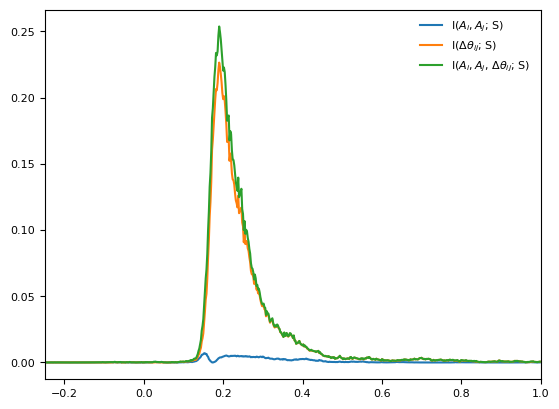

In [14]:
# Cross-spectrum z = x · conj(y): encodes both amplitude product and phase difference
z = data[:, 0] * np.conj(data[:, 1])

A    = np.abs(z).values                           # joint amplitude (envelope product |z|)
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)  # phase difference wrapped to [0, π]

# Stimulus labels: coupling amplitude linearly scaled from 0 to 100, tiled over time
labels = np.tile(np.expand_dims(np.linspace(0, 100, ntrials), 1), dphi.shape[1])

# I(A; S) — MI between joint amplitude and stimulus
I_S_R1 = mi_fcn_time(A[None], labels[None], False, True)
plt.plot(data.times, I_S_R1)

# I(Δθ; S) — MI between phase difference and stimulus
I_S_R2 = mi_fcn_time(dphi[None], labels[None], False, True)
plt.plot(data.times, I_S_R2)

# I(A, Δθ; S) — joint MI; input shape (2, ntrials, times)
I_S_R1_R2 = mi_fcn_time(np.stack((A, dphi)), labels[None], False, True)
plt.plot(data.times, I_S_R1_R2)

plt.legend(
    [
        r"I($A_{i}, A_{j}$; S)",
        r"I($\Delta\theta_{ij}$; S)",
        r"I($A_{i}, A_{j}$, $\Delta\theta_{ij}$; S)",
    ],
    frameon=False,
)

plt.xlim(-0.25, 1)

#### 6) PID — redundancy, synergy and unique information

- **Redundancy** R = min(I(A;Y), I(Δθ;Y)) — information shared by both predictors.
- **Synergy** S = I(A,Δθ;Y) − max(I(A;Y), I(Δθ;Y)) — extra information from the joint variable.
- **Unique** U(A) = I(A;Y) − R; U(Δθ) = I(Δθ;Y) − R — information exclusive to each predictor.

In [15]:
# PID decomposition (min-redundancy approximation):
#   Redundancy = min(I(A;S), I(Δθ;S))  — information shared by both predictors
#   Synergy    = I(A,Δθ;S) − max(I(A;S), I(Δθ;S)) — extra information from the joint variable
red = np.minimum(I_S_R2, I_S_R1)
syn = I_S_R1_R2 - np.maximum(I_S_R2, I_S_R1)

(-0.25, 1.0)

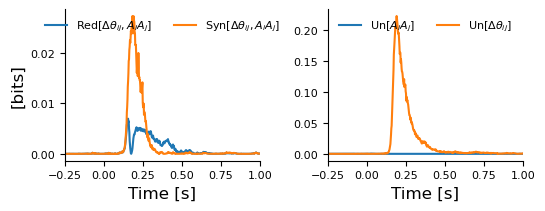

In [16]:
plt.figure(figsize=(15 / 2.54, 5 / 2.54))

# Left panel: redundancy and synergy over time
ax = plt.subplot(121)
plt.plot(data.times, red)
plt.plot(data.times, syn)
plt.legend(
    [r"Red[$\Delta\theta_{ij}, A_{i}A_{j}$]", r"Syn[$\Delta\theta_{ij}, A_{i}A_{j}$]"],
    frameon=False,
    loc="upper center",
    ncol=2,
)
plt.xlim(-1, 1)
[ax.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("[bits]", fontsize=12)
plt.xlim(-0.25, 1)

# Right panel: unique information carried by A and Δθ respectively
# U(A) = I(A;S) − R,  U(Δθ) = I(Δθ;S) − R
ax = plt.subplot(122)
plt.plot(data.times, I_S_R1 - red)
plt.plot(data.times, I_S_R2 - red)
plt.legend(
    [r"Un[$A_{i}A_{j}$]", r"Un[$\Delta\theta_{ij}$]"],
    frameon=False,
    loc="upper center",
    ncol=2,
)
[ax.spines[key].set_visible(False) for key in ["top", "right"]]

plt.subplots_adjust(wspace=0.35)
plt.xlabel("Time [s]", fontsize=12)
plt.xlim(-0.25, 1)

#### 7) Figure assembly and export

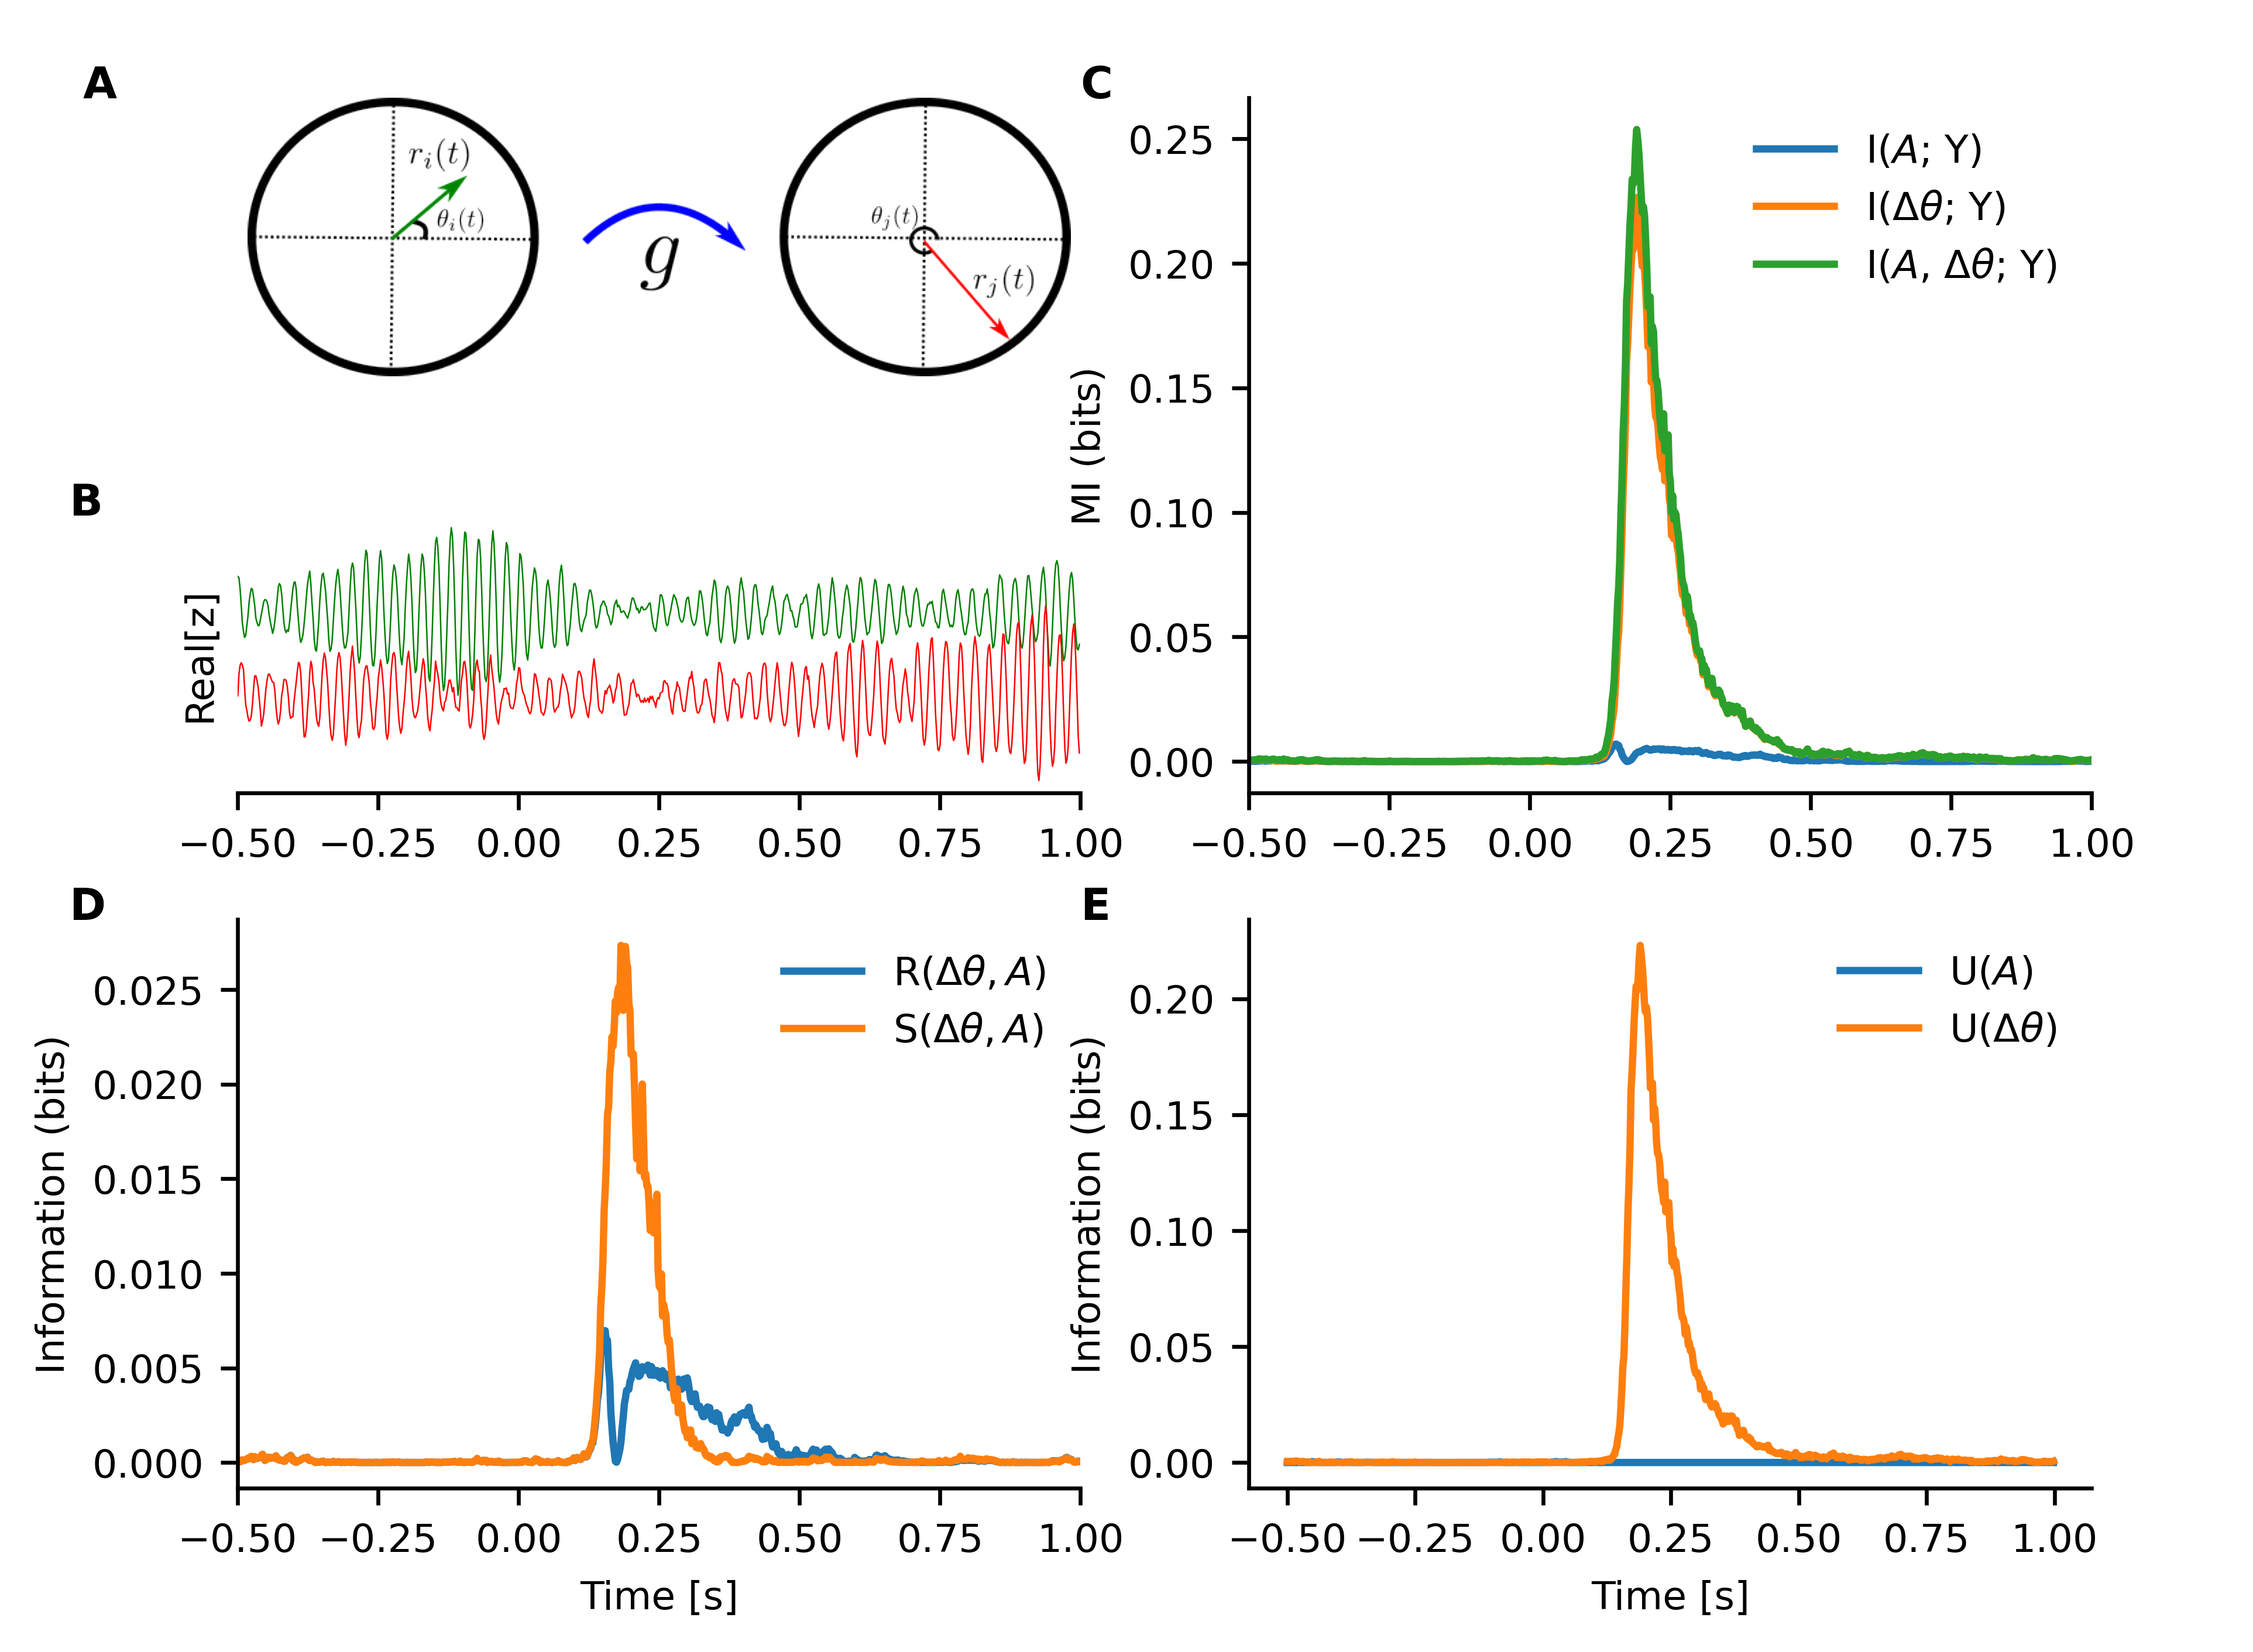

In [17]:
import plot
from PIL import Image

fig = plt.figure(figsize=(6.0, 4.5), dpi=600)

# Two-column layout equally distributed around the figure centre (0.50):
#   Col 1 (left):  left=0.06, right=0.46  (centre = 0.26, width = 0.40)
#   Col 2 (right): left=0.54, right=0.94  (centre = 0.74, width = 0.40)
#   Gap = 0.08; wspace for gs3 = gap / col_width = 0.08 / 0.40 = 0.20
#   → D/E panels align exactly with col 1 / col 2
gs1 = fig.add_gridspec(nrows=2, ncols=1, left=0.06, right=0.46,
                       bottom=0.52, top=0.96, hspace=0.5)   # panels A + B (left, top)
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.54, right=0.94,
                       bottom=0.52, top=0.96)               # panel C (right, top)
gs3 = fig.add_gridspec(nrows=1, ncols=2, left=0.06, right=0.94,
                       bottom=0.08, top=0.44, wspace=0.20)  # panels D + E (bottom)

ax1 = plt.subplot(gs1[0])   # A: cartoon schematic
ax2 = plt.subplot(gs1[1])   # B: example time series
ax3 = plt.subplot(gs2[0])   # C: MI curves
ax4 = plt.subplot(gs3[0])   # D: redundancy / synergy
ax5 = plt.subplot(gs3[1])   # E: unique information

# ── PANEL A: cartoon schematic ──────────────────────────────────────────────
plt.sca(ax1)
im = Image.open("../figures/hopf_cartoon.png")
plt.imshow(im)
plt.axis("off")

# ── PANEL B: example oscillator time series (last trial, highest coupling) ──
plt.sca(ax2)
x, y = data[-1].real
# z-score each node and offset x by +3 so traces don't overlap
x = (x - x.mean("times")) / x.std("times") + 3
y = (y - y.mean("times")) / y.std("times")
plt.plot(x.times, x, lw=0.3, c="g")
plt.plot(y.times, y, lw=0.3, c="r")
plt.ylabel("Real[z]")
plt.yticks([])
[ax2.spines[key].set_visible(False) for key in ["top", "right", "left"]]
plt.xlim(-0.5, 1)

# ── PANEL C: stimulus-related MI for amplitude, phase-difference, and joint ──
plt.sca(ax3)
plt.plot(data.times, I_S_R1)      # I(A; Y)
plt.plot(data.times, I_S_R2)      # I(Δθ; Y)
plt.plot(data.times, I_S_R1_R2)   # I(A, Δθ; Y)
plt.xlim(-0.5, 1)
plt.legend(
    [r"I($A$; Y)", r"I($\Delta\theta$; Y)", r"I($A$, $\Delta\theta$; Y)"],
    frameon=False,
)
plt.ylabel("MI (bits)")
[ax3.spines[key].set_visible(False) for key in ["top", "right"]]

# ── PANEL D: redundancy and synergy ──────────────────────────────────────────
plt.sca(ax4)
plt.plot(data.times, red)
plt.plot(data.times, syn)
plt.legend(
    [r"R($\Delta\theta, A$)", r"S($\Delta\theta, A$)"],
    frameon=False,
)
[ax4.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]")
plt.ylabel("Information (bits)")
plt.xlim(-0.5, 1)

# ── PANEL E: unique information per predictor ─────────────────────────────
# Clip prevents artefactual negative values from numerical noise in the MI estimator
plt.sca(ax5)
plt.plot(data.times, np.clip(I_S_R1 - red, -10000, np.inf))  # U(A)
plt.plot(data.times, np.clip(I_S_R2 - red, -1000, np.inf))   # U(Δθ)
plt.legend(
    [r"U($A$)", r"U($\Delta\theta$)"],
    frameon=False,
)
[ax5.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]")
plt.ylabel("Information (bits)")

# Panel letter labels at consistent positions across all axes
bg = plot.Background(visible=False)
plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3, ax4, ax5],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.2] * 5,
    ypos=[1.0] * 5,
)

plt.savefig("../figures/Figure3.pdf", bbox_inches='tight', pad_inches=0.02)

Figure 3: Phase vs. amplitude encoding encoding in the Hopf model. (A) Simulation of two Stuart-Landau
oscillators (See Eq. 18; using the same parameters for both nodes a = −5; ω = 2π40 Hz; η = 0.0001;
and coupling strength C12 = 1) coupled via a unidirectional link from Xi to Xj. The coupling strength g
among nodes was transiently modulated from 0 to 0.4 ms according to g(t) = 8Y/(2π f ), where Y was the
maximum coupling amplitude which was increased from 1 to 100 across trials (n = 5000). (B) Real part of
the (Real(Z)) time-series for the simulated SL system. (C) Stimulus-related information contained in the
broadband joint-amplitude (blue; A = abs(Zi Z∗
j )); the phase-difference (orange; ∆θ = arg(Zi Z∗
j )), and both
(green). (D) The redundant (blue) and synergistic (green) information between the phase-difference and the
joint-amplitude carried about the stimulus. (E) The unique information carried about the stimulus by the
phase-difference (orange) and the joint-amplitude (blue). 

#### 8) Supplementary Figure 3S — sensitivity to the oscillator's natural frequency

In [ ]:
def run_sl_pid_sweep(f, ntrials, seed_offset=0):
    s_local = 8 / (2 * np.pi * f)
    gaussian_local = np.exp(-(timestim**2) / (2 * s_local**2))
    coupling_local = np.zeros_like(time)
    coupling_local[ind] = gaussian_local

    CS_local = np.linspace(1, 100, ntrials)
    seeds_local = np.random.randint(0, 100000, ntrials) + seed_offset
    coupling_local = CS_local[:, None] * coupling_local

    out_local = simulate_loop(
        1 * C,
        coupling_local,
        f,
        -5,
        fsamp,
        beta,
        Npoints,
        None,
        seeds_local,
        "cpu",
        decim,
    )

    data_local = xr.DataArray(
        np.stack(out_local),
        dims=("trials", "roi", "times"),
        coords=(range(ntrials), ["x", "y"], time[::decim]),
    ).sel(times=slice(-0.5, 1))

    z_local = data_local[:, 0] * np.conj(data_local[:, 1])
    A_local = np.abs(z_local).values
    dphi_local = np.angle(z_local)
    dphi_local = np.abs((dphi_local + np.pi) % (2 * np.pi) - np.pi)

    labels_local = np.tile(
        np.expand_dims(np.linspace(0, 100, ntrials), 1), dphi_local.shape[1]
    )

    I_A = np.asarray(mi_fcn_time(A_local[None], labels_local[None], False, True))
    I_dphi = np.asarray(mi_fcn_time(dphi_local[None], labels_local[None], False, True))
    I_joint = np.asarray(
        mi_fcn_time(np.stack((A_local, dphi_local)), labels_local[None], False, True)
    )

    red_local = np.minimum(I_A, I_dphi)
    syn_local = I_joint - np.maximum(I_A, I_dphi)
    unique_A_local = I_A - red_local
    unique_dphi_local = I_dphi - red_local

    win = (data_local.times.values >= -0.25) & (data_local.times.values <= 1)
    peak = lambda x: float(x[win].max())

    return {
        "I_A": peak(I_A),
        "I_dphi": peak(I_dphi),
        "I_joint": peak(I_joint),
        "red": peak(red_local),
        "syn": peak(syn_local),
        "unique_A": peak(unique_A_local),
        "unique_dphi": peak(unique_dphi_local),
    }

# Frequency sweep: brackets both the empirical LFP peak (~20 Hz) and the
# main-text modeling choice (40 Hz), with enough spread to reveal a trend.
sweep_freqs = [10, 20, 30, 40, 50, 60, 70, 80]
ntrials_sweep = 1500

sweep_results = {}
for fi in tqdm(sweep_freqs):
    sweep_results[fi] = run_sl_pid_sweep(fi, ntrials_sweep, seed_offset=int(fi * 1000))

100%|██████████| 8/8 [04:17<00:00, 32.18s/it]


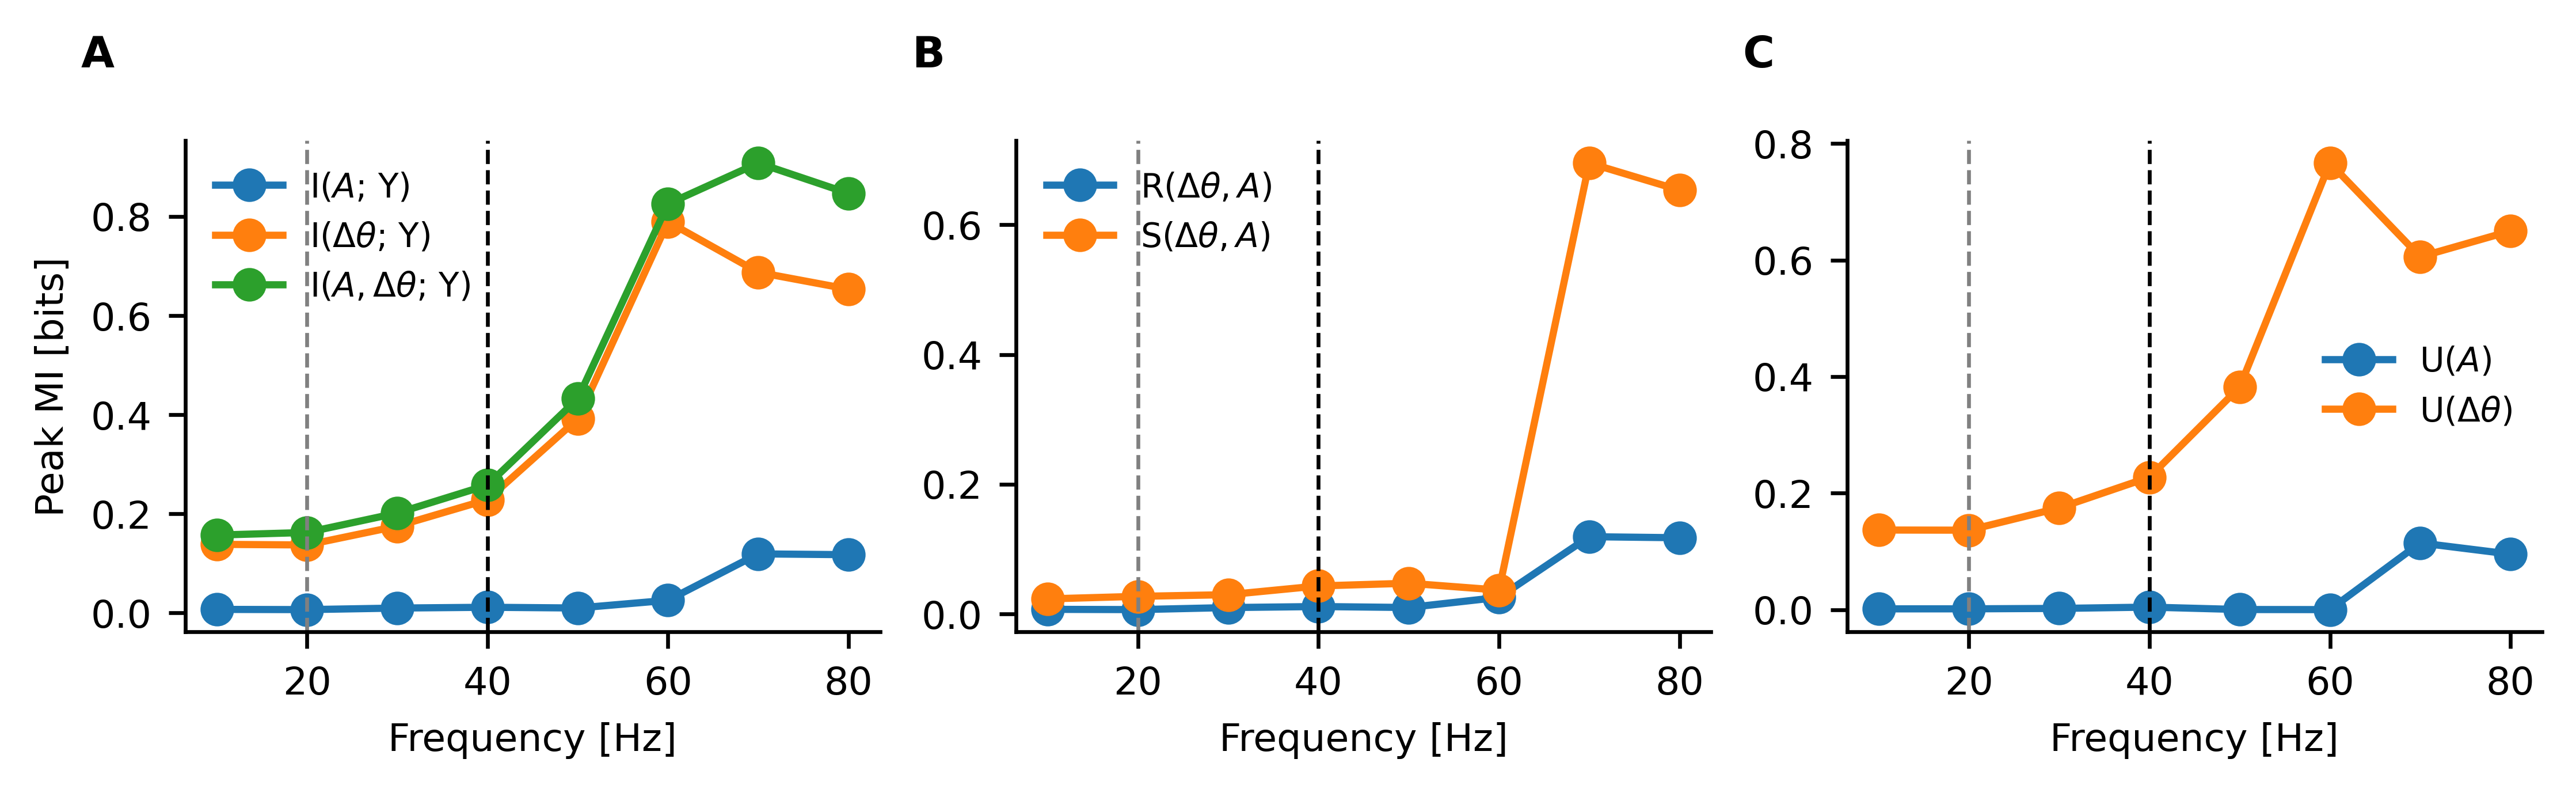

In [19]:
# Collect peak values across the sweep into arrays indexed by frequency.
I_A_peak = np.array([sweep_results[fi]["I_A"] for fi in sweep_freqs])
I_dphi_peak = np.array([sweep_results[fi]["I_dphi"] for fi in sweep_freqs])
I_joint_peak = np.array([sweep_results[fi]["I_joint"] for fi in sweep_freqs])
red_peak = np.array([sweep_results[fi]["red"] for fi in sweep_freqs])
syn_peak = np.array([sweep_results[fi]["syn"] for fi in sweep_freqs])
unique_A_peak = np.array([sweep_results[fi]["unique_A"] for fi in sweep_freqs])
unique_dphi_peak = np.array([sweep_results[fi]["unique_dphi"] for fi in sweep_freqs])

fig3s, axes3s = plt.subplots(1, 3, figsize=(7.5, 2.4), dpi=600)

# ── PANEL A: peak MI vs. frequency (amplitude / phase-difference / joint) ────
ax = axes3s[0]
ax.plot(sweep_freqs, I_A_peak, marker="o")
ax.plot(sweep_freqs, I_dphi_peak, marker="o")
ax.plot(sweep_freqs, I_joint_peak, marker="o")
ax.legend(
    [r"I($A$; Y)", r"I($\Delta\theta$; Y)", r"I($A,\Delta\theta$; Y)"],
    frameon=False, fontsize=SMALL_SIZE - 1,
)
ax.set_ylabel("Peak MI [bits]")
ax.set_xlabel("Frequency [Hz]")
[ax.spines[k].set_visible(False) for k in ["top", "right"]]

# ── PANEL B: peak redundancy / synergy vs. frequency ─────────────────────────
ax = axes3s[1]
ax.plot(sweep_freqs, red_peak, marker="o")
ax.plot(sweep_freqs, syn_peak, marker="o")
ax.legend(
    [r"R($\Delta\theta,A$)", r"S($\Delta\theta,A$)"],
    frameon=False, fontsize=SMALL_SIZE - 1,
)
ax.set_xlabel("Frequency [Hz]")
[ax.spines[k].set_visible(False) for k in ["top", "right"]]

# ── PANEL C: peak unique information vs. frequency ───────────────────────────
ax = axes3s[2]
ax.plot(sweep_freqs, unique_A_peak, marker="o")
ax.plot(sweep_freqs, unique_dphi_peak, marker="o")
ax.legend(
    [r"U($A$)", r"U($\Delta\theta$)"],
    frameon=False, fontsize=SMALL_SIZE - 1,
)
ax.set_xlabel("Frequency [Hz]")
[ax.spines[k].set_visible(False) for k in ["top", "right"]]

# Reference lines: ~20 Hz empirical peak (gray) and 40 Hz main-text choice (black).
for ax in axes3s:
    ax.axvline(20, color="gray", ls="--", lw=0.8)
    ax.axvline(40, color="k", ls="--", lw=0.8)

plot.add_panel_letters(fig3s, axes=list(axes3s), fontsize=MEDIUM_SIZE, xpos=-0.15, ypos=1.15)

plt.tight_layout()
plt.savefig("../figures/Figure3S.pdf", bbox_inches="tight", pad_inches=0.02)

### Supplementary Figure 3S caption

#### 9) Supplementary Figure 3S2 — robustness to broadband 1/f background activity

In [28]:
# Real-valued 1/f (pink, alpha=1) noise generator: FFT a white-noise array,
# scale its amplitude spectrum by 1/sqrt(f) (power ~ 1/f), zero the DC term,
# and inverse-FFT. Vectorized over all leading axes at once (operates along
# the last axis, time).
def pink_noise(shape, fs, rng):
    n = shape[-1]
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    white = rng.standard_normal(shape)
    spec = np.fft.rfft(white, axis=-1)
    scale = np.zeros_like(freqs)
    scale[1:] = 1 / np.sqrt(freqs[1:])
    pink = np.fft.irfft(spec * scale, n=n, axis=-1)
    return pink / pink.std()

rng = np.random.default_rng(0)
fs_decim = fsamp / decim  # sampling rate of the already-decimated `data`
clean_std = float(data.real.std())

noise_scales = [0.0, 0.5, 2.0]
noise_labels = ["Clean", "Moderate 1/f", "Strong 1/f"]
noise_linestyles = ["-", "--", ":"]

data_by_condition = {}
for scale in noise_scales:
    if scale == 0.0:
        data_by_condition[scale] = data
        continue
    pink_re = pink_noise(data.shape, fs_decim, rng) * clean_std * scale
    pink_im = pink_noise(data.shape, fs_decim, rng) * clean_std * scale
    data_by_condition[scale] = data + (pink_re + 1j * pink_im)

In [ ]:
# Recompute the same amplitude/phase-difference features and GC-MI/PID
# pipeline as the main figure (cells above), once per noise condition.
results_noise = {}
for scale in noise_scales:
    d = data_by_condition[scale]
    z_n = d[:, 0] * np.conj(d[:, 1])

    A_n = np.abs(z_n).values
    dphi_n = np.angle(z_n)
    dphi_n = np.abs((dphi_n + np.pi) % (2 * np.pi) - np.pi)

    I_A_n = np.asarray(mi_fcn_time(A_n[None], labels[None], False, True))
    I_dphi_n = np.asarray(mi_fcn_time(dphi_n[None], labels[None], False, True))
    I_joint_n = np.asarray(
        mi_fcn_time(np.stack((A_n, dphi_n)), labels[None], False, True)
    )

    red_n = np.minimum(I_A_n, I_dphi_n)
    syn_n = I_joint_n - np.maximum(I_A_n, I_dphi_n)

    results_noise[scale] = {
        "I_A": I_A_n,
        "I_dphi": I_dphi_n,
        "I_joint": I_joint_n,
        "red": red_n,
        "syn": syn_n,
        "unique_A": I_A_n - red_n,
        "unique_dphi": I_dphi_n - red_n,
    }

In [ ]:
colors3 = plt.rcParams["axes.prop_cycle"].by_key()["color"][:3]

fig3s2, axes3s2 = plt.subplots(
    3, 3, figsize=(7.5, 6.5), dpi=600, sharex=True, sharey="row"
)

row_titles = [
    "Mutual information",
    "Redundancy / synergy",
    "Unique information",
]

for col, scale in enumerate(noise_scales):
    r = results_noise[scale]

    ax = axes3s2[0, col]
    ax.plot(data.times, r["I_A"], color=colors3[0], lw=1)
    ax.plot(data.times, r["I_dphi"], color=colors3[1], lw=1)
    ax.plot(data.times, r["I_joint"], color=colors3[2], lw=1)
    ax.set_title(noise_labels[col], fontsize=SMALL_SIZE)
    [ax.spines[k].set_visible(False) for k in ["top", "right"]]

    ax = axes3s2[1, col]
    ax.plot(data.times, r["red"], color=colors3[0], lw=1)
    ax.plot(data.times, r["syn"], color=colors3[1], lw=1)
    [ax.spines[k].set_visible(False) for k in ["top", "right"]]

    ax = axes3s2[2, col]
    ax.plot(data.times, r["unique_A"], color=colors3[0], lw=1)
    ax.plot(data.times, r["unique_dphi"], color=colors3[1], lw=1)
    [ax.spines[k].set_visible(False) for k in ["top", "right"]]

# Row labels and per-row quantity legends on the leftmost column only.
axes3s2[0, 0].set_ylabel(f"{row_titles[0]}\n[bits]")
axes3s2[0, 0].legend(
    [r"I($A$;Y)", r"I($\Delta\theta$;Y)", r"I($A,\Delta\theta$;Y)"],
    frameon=False, fontsize=SMALL_SIZE - 2, loc="upper right",
)
axes3s2[1, 0].set_ylabel(f"{row_titles[1]}\n[bits]")
axes3s2[1, 0].legend(
    [r"R($\Delta\theta,A$)", r"S($\Delta\theta,A$)"],
    frameon=False, fontsize=SMALL_SIZE - 2, loc="upper right",
)
axes3s2[2, 0].set_ylabel(f"{row_titles[2]}\n[bits]")
axes3s2[2, 0].legend(
    [r"U($A$)", r"U($\Delta\theta$)"],
    frameon=False, fontsize=SMALL_SIZE - 2, loc="upper right",
)

for ax in axes3s2[-1]:
    ax.set_xlabel("Time [s]")
for ax in axes3s2.ravel():
    ax.set_xlim(-0.25, 1)

plot.add_panel_letters(
    fig3s2, axes=list(axes3s2[:, 0]), fontsize=MEDIUM_SIZE, xpos=-0.3, ypos=1.15
)

plt.tight_layout()
plt.savefig("../figures/Figure3S2.pdf", bbox_inches="tight", pad_inches=0.02)

### Supplementary Figure 3S2 caption

#### 10) Supplementary Figure 3S3 — effect of band-limited filtering under 1/f contamination

In [37]:
l_freq, h_freq = 35.0, 45.0

results_filtered = {}
for scale in noise_scales:
    d = data_by_condition[scale]

    re_filt = filter_data(
        np.ascontiguousarray(d.real.values), fs_decim, l_freq, h_freq, verbose=False
    )
    im_filt = filter_data(
        np.ascontiguousarray(d.imag.values), fs_decim, l_freq, h_freq, verbose=False
    )
    d_filt = re_filt + 1j * im_filt

    z_f = d_filt[:, 0] * np.conj(d_filt[:, 1])
    A_f = np.abs(z_f)
    dphi_f = np.angle(z_f)
    dphi_f = np.abs((dphi_f + np.pi) % (2 * np.pi) - np.pi)

    I_A_f = np.asarray(mi_fcn_time(A_f[None], labels[None], False, True))
    I_dphi_f = np.asarray(mi_fcn_time(dphi_f[None], labels[None], False, True))
    I_joint_f = np.asarray(
        mi_fcn_time(np.stack((A_f, dphi_f)), labels[None], False, True)
    )

    results_filtered[scale] = {
        "I_A": I_A_f,
        "I_dphi": I_dphi_f,
        "I_joint": I_joint_f,
    }

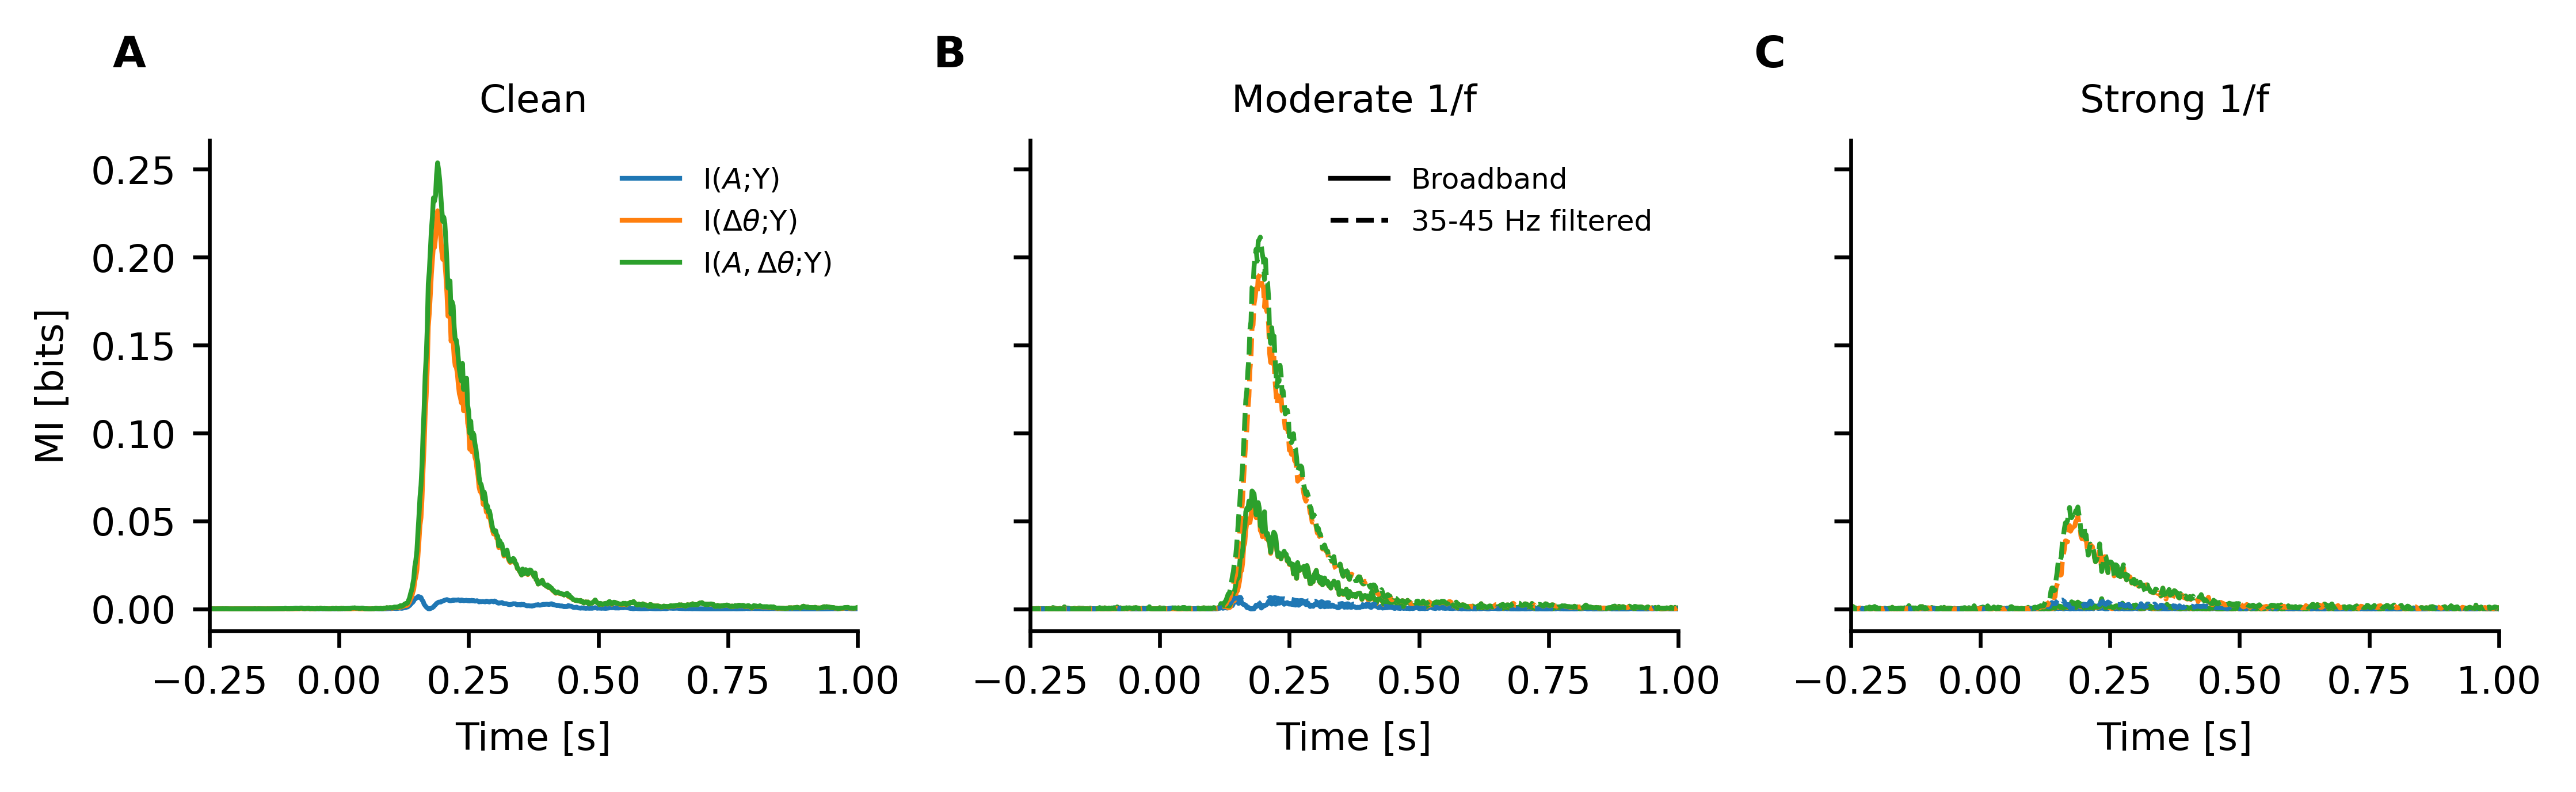

In [38]:
from matplotlib.lines import Line2D

fig3s3, axes3s3 = plt.subplots(1, 3, figsize=(7.5, 2.4), dpi=600, sharey=True)

for col, scale in enumerate(noise_scales):
    ax = axes3s3[col]
    r = results_noise[scale]
    ax.plot(data.times, r["I_A"], color=colors3[0], lw=1, ls="-")
    ax.plot(data.times, r["I_dphi"], color=colors3[1], lw=1, ls="-")
    ax.plot(data.times, r["I_joint"], color=colors3[2], lw=1, ls="-")

    if scale != 0.0:
        rf = results_filtered[scale]
        ax.plot(data.times, rf["I_A"], color=colors3[0], lw=1, ls="--")
        ax.plot(data.times, rf["I_dphi"], color=colors3[1], lw=1, ls="--")
        ax.plot(data.times, rf["I_joint"], color=colors3[2], lw=1, ls="--")

    ax.set_title(noise_labels[col], fontsize=SMALL_SIZE)
    ax.set_xlabel("Time [s]")
    ax.set_xlim(-0.25, 1)
    [ax.spines[k].set_visible(False) for k in ["top", "right"]]

axes3s3[0].set_ylabel("MI [bits]")
axes3s3[0].legend(
    [r"I($A$;Y)", r"I($\Delta\theta$;Y)", r"I($A,\Delta\theta$;Y)"],
    frameon=False, fontsize=SMALL_SIZE - 2, loc="upper right",
)
axes3s3[1].legend(
    [Line2D([0], [0], color="k", lw=1, ls="-"), Line2D([0], [0], color="k", lw=1, ls="--")],
    ["Broadband", f"{l_freq:.0f}-{h_freq:.0f} Hz filtered"],
    frameon=False, fontsize=SMALL_SIZE - 2, loc="upper right",
)

plot.add_panel_letters(fig3s3, axes=list(axes3s3), fontsize=MEDIUM_SIZE, xpos=-0.15, ypos=1.15)

plt.tight_layout()
plt.savefig("../figures/Figure3S3.pdf", bbox_inches="tight", pad_inches=0.02)

### Supplementary Figure 3S3 caption

Figure 3S3: Effect of band-pass filtering on stimulus information under broadband 1/f contamination. Columns show the three 1/f contamination levels of Figure 3S2 (Clean / Moderate 1/f / Strong 1/f), each plotting the same mutual information curves as the top row of Figure 3S2 — between the stimulus and the joint amplitude, the phase difference, and their combination — computed on the raw, broadband signal (solid lines). For the Moderate and Strong conditions, the same curves recomputed after band-pass filtering the signal to 35-45 Hz, around the oscillator's 40 Hz natural frequency, prior to extracting amplitude and phase-difference features, are overlaid as dashed lines of the same color; the Clean condition has no such overlay since there is no broadband contamination to filter out. All panels share the same y-axis, so the extent to which band-limited filtering recovers, preserves, or fails to recover the encoding present under broadband contamination can be read directly by comparing the solid and dashed curves within each column.